# MCMC Theory Primer

This notebook is a guided skeleton for learning the Markov-chain theory needed for Metropolis--Hastings, Gibbs sampling, etc.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
plt.style.use("seaborn-v0_8-whitegrid")


## 1. The Markov property and transition kernels

A process $X_0,X_1,\ldots$ is Markov when the distribution of the next state, conditional on the entire past, depends only on the current state:

$$
P(X_{t+1}\in A\mid X_0,\ldots,X_t)
=
P(X_{t+1}\in A\mid X_t).
$$

For a finite state space, a transition matrix $P$ contains probabilities

$$
P_{ij}=P(X_{t+1}=j\mid X_t=i).
$$

**Markov Property** 

A sequence of dependent random variables is said to have the Markov property if the past and future are conditionally independent given then present. In other words, if the current time step is $t$, then the probability of a future state happening dependent on the current and past states is equal to the probability of the future state given just the present state:  
$$P(X_{t+1} = x_{t+1} \mid X_t=x_t, X_{t-1}=x_{t-1}, \ldots, X_1=x_1) = P(X_{t+1} = x_{t+1} \mid X_t = x_t)\;.$$
If a sequence satisfies this property it's called a Markov Chain. Additionally, a Markov chain is *time homogeneous* if the probabilities in the
above equation do not depend on $t$. In other words the following two give equal probability:
$$
P(X_{t+1} = j \mid X_t = i) = P(X_1 = j \mid X_0 = i)\;.
$$

**Transition Matrix (Discrete MC)**

The transition matrix is a matrix $P$ with $ij$-th entry representing the probability that the next-step transition is from state $i$ to state $j$, i.e. $P_{ij} = P(X_1 = j \mid X_0 = i)$. If the state space (denoted $S$) has $k$ possible states, then the transition probability matrix is a $k \times k$ square matrix. These entries are all non-negative (since they are probabilities) and the rows sum to $1.0$ since each row is a probability distribution. The summing to $1.0$ can be mathematically seen by: 
$$
\sum_j P_{ij} = \sum_{j} P(X_1 = j \mid X_0 = i) = \sum_j \frac{P(X_1 = j, X_0 = i)}{P(X_0 = i)} = \frac{P(X_0 = i)}{P(X_0 = i)} = 1
$$
where the sum on the second last statement becomes $P(X_0 = i)$ by the law of total probability. Such matrix (where the rows sum to $1.0$) is called a *stochastic matrix*. 

**Transition Kernel (Continuous MC)**

When $X_t \in \mathbb{R}^p$, we cannot use a finite matrix, but instead use a transition kernel
$$
    P(x,A) = P(X_{t+1} \in A \mid X_t = x)\;.
$$
The transition kernel gives the probability that the next state lies in the set $A$, given that the current state is $x$. If the transition kernel has a density, then we may write it as:
$$
    p(x, A) = \int_A p(y\mid x)dy\;.
$$
One can think of a transitiion kernel as the continuous-state version of a transition matrix's row.

**Evolution of the Chain's Distribution**

Suppose the initial state has distribution $X_0 \sim \mu_0$. Given a finite chain, we have that the distribution after a single transition is given by
$$
    \mu_1 = \mu_0 P\;,
$$
and after $t$ transitions,
$$
    \mu_t = \mu_0 P^t\;.
$$
For a continuous-state chain, 
$$
    \mu_{t+1}(A) = \int P(x,A)\mu_t(dx)\;,
$$
which we see is the law of total probability: we are average the probability of moving into $A$ over all possible current states $x$.

**Limiting Distribution**

For a Markov chain $X_0, X_1, \ldots,$ with transition matrix $P$, a limiting distribution for said chain is a probability distribution $\lambda$ with the
property that for all $i$ and $j$,
$$
\lim_{n\rightarrow \infty} P_{ij}^n = \lambda_j\;.
$$
We interpret $\lambda_j$ as the long-term probability that the chain hits state $j$, i.e. $P(X_n = j) = \lambda_j$, for any initial distribution and all $j$. Uniqueness of limits guarantees that if a Markov chain has a limiting distribution then it is the unique distribution.  

In [ ]:
# A three-state transition matrix
P = np.array([
    [0.70, 0.20, 0.10],
    [0.10, 0.60, 0.30],
    [0.20, 0.30, 0.50],
])

print("Row sums:", P.sum(axis=1))
assert np.all(P >= 0)
assert np.allclose(P.sum(axis=1), 1.0)


Row sums: [1. 1. 1.]


### Simulate a finite-state Markov chain

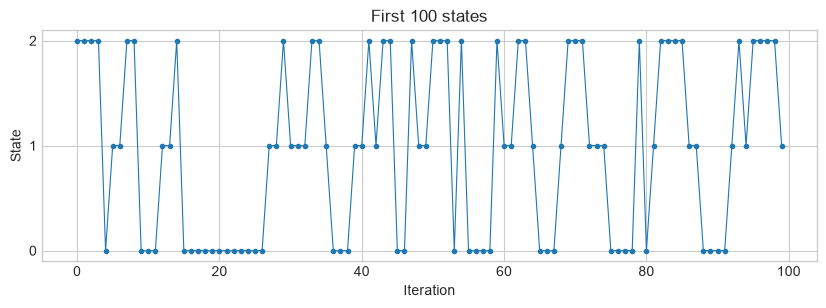

In [ ]:
def simulate_markov_chain(P, initial_state, n_steps, rng):
    """Simulate a finite-state Markov chain with transition matrix P."""
    states = np.empty(n_steps, dtype=int)
    states[0] = initial_state

    for t in range(1, n_steps):
        current_state = states[t - 1]
        states[t] = rng.choice(P.shape[0], p=P[current_state])

    return states

# CODING EXERCISE: change the initial state and number of steps.
chain = simulate_markov_chain(P, initial_state=2, n_steps=5_000, rng=rng)

plt.figure(figsize=(10, 3))
plt.plot(chain[:100], marker="o", markersize=3, linewidth=0.8)
plt.yticks(range(P.shape[0]))
plt.xlabel("Iteration")
plt.ylabel("State")
plt.title("First 100 states")
plt.show()


## 2. Stationary distributions

A distribution $\pi$ is stationary for $P$ when

$$
\pi P=\pi.
$$

If $X_t\sim\pi$, one more application of the transition rule leaves the distribution unchanged. This is the design goal of MCMC: construct a transition mechanism with the desired posterior as a stationary distribution.

If the initial distribution is a stationary distribution, then $X_0, X_1, X_2, \ldots,$ is a sequence of identically distributed random variables. It does not mean that the random varaibles are independent. 

If a Markov chain has a limiting distribution then that distribution is a stationary distribution. That is, if $\pi$ is the limiting distribution of a Markov chain with transition matrix $P$, then $\pi$ is a stationary distribution. This happens because, if we denote $\alpha$ to be the initial distribution, we have that
$$
\pi = \lim_{n\rightarrow \infty} \alpha P^{n}_{ij} = \lim_{n \rightarrow \infty} (\alpha P^{n-1}_{ij})P = \pi P\;,
$$
which shows, by definition, that $\pi$ is a stationary distribution. We **note** that the converse is not true: a stationary distribution need not be the limiting distribution. 

A large class of Markov chains that have unique stationary distributions that are the limiting distributions of the chain are called *regular Markov chains*. Such a class of Markov chains have a transition matrix which is *regular*. A *regular* transition matrix (or just matrix) is one where **some power** of said matrix, say $P$, is positive. That is, $P^n > 0$, for some $n \geq 1$. 

### Example

In [ ]:
P = np.array(
    [
        [0.0, 0.5, 0.5],
        [1.0, 0.0, 0.0],
        [0.5, 0.5, 0.0]
    ]
)

# P is regular since P^4 is positive
P4 = P @ P @ P @ P
(P4 > 0).all()

np.True_

A Markov chain whose transition matrix $P$ is regular has a limiting distribution, which is the unique, positive, stationary distribution of the chain. i.e there exists a unique probability vector $\pi > 0$, such that 
$$
    \lim_{n \rightarrow \infty} P^n_{ij} = \pi_j\;,
$$
for all $i,j$, where 
$$
    \sum_{i} \pi_i P_{ij} = \pi_j\;.
$$

Equivalently, there exists a stochastic matrix $Lambda$ such that $\lim_{n \rightarrow \infty} P^n = \Lambda$ where $\Lambda$ has equal rows with common row $\pi$, and $\pi$ is the unique probability vector, which satisfies $\pi P = \pi$.

One way to tell if a stochastic matrix is not regular is if for some power $n$, all the $0$'s in $P^n$ appear in the same locations as all the $0$'s in $P^{n+1}$, then they will appear in the same locations for all higher powers, and the matrix is not regular.

In [ ]:
# Example of the technique for detecting non-regular matrix
P = np.array(
    [
        [0, 0, 0, 0, 1],
        [0.25, 0, 0, 0.5, 0.25],
        [0, 0, 1, 0, 0],
        [0, 0, 0.5, 0.5, 0],
        [0.25, 0.5, 0, 0, 0.25]
    ]
)

# Notice that P^4 and P^5 have spots where 0s are in the same location
P4 = P@P@P@P
P5 = P4@P

# checking whether any entries are both zero at the same entry point
result = np.any((P4 == 0) & (P5 == 0))
location = np.argwhere((P4 == 0) & (P5 == 0))
print(f"Do they share entries equally zero?: {result}\nFound at entries: {location}")

Do they share entries equally zero?: True
Found at entries: [[2 0]
 [2 1]
 [2 3]
 [2 4]
 [3 0]
 [3 1]
 [3 4]]


For a continuous-state space, a distribution $\pi$ is stationary when
$$
    \pi(A) = \int P(x,A)\pi(dx)
$$
for every measurable set $A$. 

### Stationarity is not the same as convergence


The equation 
$$
    \pi P = \pi
$$
only says that $\pi$ is preserved if the chain already has distribution $\pi$. This property does not 
allow us to conlude:
$$
    \mu_0 P \rightarrow \pi
$$
from an arbitrary initial distribution $\mu_0$.

For example, consider
$$
P=
\begin{pmatrix}
0&1\\
1&0
\end{pmatrix}.
$$
The distribution
$$
\pi=(1/2,1/2)
$$
is stationary. But a chain starting in state 0 alternates deterministically:
$$
0,1,0,1,0,1,\ldots
$$
The distribution of $X_t$ alternates between a point mass at 0 and a point mass at 1. It does not converge to $\pi$.

### Detailed Balance

Detailed balance is a method to establish stationarity. For a finite chain, detailed balance requires:
$$
    \pi_i P_{ij} = \pi_j P_{ji}\;, 
$$
for every pair $i,j$. The left hand side of the equality represent the stationary probability flow from $i$ to $j$. The equation above, when satisfied, tells us that the probability flow from $i$ to $j$ should match the reverse flow from $j$ to $i$. This implies stationarity because if we sum the detailed-balance equation above over $i$:
$$
    \sum_i \pi_i P_{ij} = \sum_i \pi_j P_{ji}
$$
we get
$$
    \sum_i \pi_i P_{ij} = \pi_j \sum_i P_{ji} = \pi_j
$$
in which the final equation is precisely the definition of stationarity. 

For **continuous-state** chains, given that transition densities exist, we may describe detailed balance by:
$$
    \pi(x)p(y\mid x) = \pi(y)p(x\mid y)\;.
$$
In general we have:
$$
\pi(dx)P(x,dy) = \pi(dy)P(y,dx)\;.
$$
Detailed balance is a sufficient condition for stationarity, but it is not necessary. (There exists MCMC algorithms which are non-reversible).

A chain satisfying detailed balance is called **reversible**. In short, a reversible chain, once it reached stationarity, means that the probability flows are balanced in aggregate. It does not mean that every move is immediately reversed.


## 3. Coniditions for Useful Chains (WIP)

The following is a list of useful properties a Markov chain should have in order for MCMC to behave well.

### Irreducibility

Irreducibility of a chain can be seen as the property that all states of the chain communicate with each other in a finite number of steps with positive probability. More formally, a Markov chain is called irreducible if it has exactly one communication class. That is, all states communicate with each other.

The following is an example of a chain that is **not** irreducible:
$$
P=
\begin{pmatrix}
0.8&0.2&0\\
0.3&0.7&0\\
0&0&1
\end{pmatrix}\;,
$$
since if the chain starts in state $2$, it remains there forever, and if it starts in states 0 or 1, it can never reach state 2. This chain has two communication classes: $\{0,1\}$ and $\{2\}$.

In the continuous case we say that the chain is irreducible if the chain can reach every set that has positive probability under the target (informal).

**Note:** Irreducibility concerns accessibility, not speed. A chain may technically be able to reach every region but there is no guarantee how long in time that would take.

### Aperiodicity

A chain is *periodic* if it is forced to return to states according to a rigid cycle. The period of a state $i$ (denoted $d(i)$) is the greatest common divisor (GCD) of all possible number of steps $n$ it takes to return to that same state, starting from that state. Mathematically, for Markov chain with transition matrix $P$ we have:
$$
    d(i) = \text{gcd}\{n > 0 : P_ii^n > 0\}\;.
$$
From this definition, starting from state $i$, we can only return to state $i$ in multiples of $d(i)$ steps. If $d(i) = 1$, state $i$ is said to be **aperiodic**. 

A Markov chain is called periodic if it is irreducible and all states have period greater than 1. It is called aperiodic if it is irreducible and all states have period equal to 1.

**Note:** Any state $i$ with the property that $P_ii > 0$ is necessarily aperiodic. Thus, a sufficient condition for an irreducible chain to be aperiodic is that $P_ii > 0$ for some $i$; i.e. one diagonal entry in $P$ is nonzero. 

### Recurrence

A state is *recurrent* if, starting from that state, the probability of eventually returning to said state is exactly 1. If the probability of returning to the
state is less than 1, then the state is said to be *transient*. For a transient state, there is a possibility that the chain will never revisit said state. 

If a state is recurrent and its average return time is finite, then said state is said to be *positive recurrent*. If the state is recurrent but the everage return time is infinite then the state is said to be *null recurrent*. 

Summary:
- **Transient** : Probability of returning $<$ 1 : average steps to return is $\infty$ : chain eventually abandons state.
- **Null Recurrent** : Probability of returning $=$ 1 : average steps to return is $\infty$ : Guaranteed to return to state, but takes longer on average.
- **Positive Recurrent** : Probability of returning $=$ 1 : average steps to return is $< \infty$ : Guaranteed to return to state, visited frequently.


### Ergodicity

For a discrete-time Markov chain to be classified as ergodic it must meet the following three criteria:

1. Irreducible;
2. Aperiodic;
3. Positive recurrent.

Ergodic chains are desired for MCMC because they have sufficiently good long-run behaviour which allows the chain to cover the sample space accurately
according to the stationary distribution. The key conclusion is the Markov-chain ergodic theorem which states:
$$
    \frac{1}{N} \sum_{i=1}^N f(X_t) \rightarrow E_{\pi}[f(X)]
$$
under appropriate conditions. The ergodic theorem is the MC counterpart of the law of large numbers. Samples need not be independent but their dependence
must be sufficiently controlled so that the long-run averages stabilize. 

## 4. MCMC (WIP)

In Bayesian inference, the distribution of interest is normally the posterior distribution:
$$
    \pi(\theta | y) = \frac{p(y|\theta)\pi_0(\theta)}{\int p(y|\theta)\pi_0(\theta)}
$$
the denominator, i.e. marginal density, is often analytically unavailable. We, yet, desire the posterior
as it allows us to compute quantities of interest such as the posterior mean, posterior variance, prediction, etc. The mentioned quantities share the form:
$$
    \int f(\theta)\pi(\theta | y)d\theta\;,
$$
where, for example: setting $f(\theta) = p(\tilde y | \theta)$, would yield the predictive distribution. The form above is by definition the expection with respect to the posterior distribution $E_{\pi}[f(\theta)]$. 

If we can make draws from $\pi$, then we may use ordinary Monte Carlo integration in order to approximate the expectation. Then, via the law of large numbers, we may get a decent estimate of $E_{\pi}[f]$. Since we mentioned that direct sampling from $\pi$ may be impossible, we need a means to do so.

MCMC achieves this goal by constructing an ergodic Markov chain with limiting distribution $\pi$. One then runs the chain long enough for it to converge to its limiting 
distribution. The final elements of the Markov sequence are then taken as samples from $\pi$. Through the law of large numbers for Markov chains, we may still, then, attain an estimate of the expectation. 

In short, MCMC is a methodology that allows one to simulate from a complex and high-dimensional probability distribution. These samples may then further be put to use to compute quantities of interest as outlined above.

MCMC algorithms are normally discrete-time Markov chains because they evolve sequentially via iterations:
$$
    \theta^{(0)} \rightarrow \theta^{(1)} \rightarrow \theta^{(2)} \rightarrow \ldots\;.
$$
The state space, however, can still be continuous. 

In the introductory sections above for Markov chains, we saw two different objects at play:
1. $X_t$: a random state;
2. $\mu_t$: the probability distribution for that state.

MCMC convergence concerns the distributions $\mu_t$, not whether the sequence $X_t$ converges to a single value. A good MCMC chain should continue moving indefinitely (to attain the limit / converge). 

Likewise, we spoke about stationarity and how stationarity $\neq$ convergence. As such, we require to answer the following two questions:
1. Does the chain preserve the desired distribution?
2. Does the chain approach that distribution from its initial state?
These questions are answered positively if our chain is ergodic, as discussed above.

## Distributional Convergence

Convergence in distribution asks whether $\mathcal{L}(X_t) \rightarrow \pi$. It measures the rate at which the system sheds its arbitrary bias of its 
starting point. The reason for this is because when we start an MCMC chain, we pick an initial distribution and then run the chain. We ideally want to 
transition from the initial distribution to the stationary distribution. By ergodicity, when $t = \infty$ the system has completely moved around the space
enough that the "memory" of where it began is completely forgotten.

We therefore need a measure to track "how much memory is left" for a finite chain. A commonly used measure is the Total Variation (VT) distance. If $\mu_t(x)$ is
the distribution of the chain at iteration $t$ starting from state $x$, and $\pi(\cdot)$ is the true target distribution, the VT distance between them is:
$$
    \|\mu_t - \pi\|_{TV} = \frac{1}{2} \sum_{x} |\mu_t(x) - \pi(x)|\;.
$$
For continuous distributions:
$$
    \|\mu_t - \pi\|_{TV} = \sup_{A} |\mu_t(A) - \pi(A)|\;. 
$$
An ergodic Markov chain guarantees that this distance goes to zero as $t \rightarrow \infty$:
$$
    \lim_{t \rightarrow \infty} \|\mu_t(x) - \pi(x)\|_{TV} = 0\;.
$$
**Mixing time** describes how long it takes for this discrepancy to become small.

## Monte Carlo Covergence

Monte Carlo convergence does not directly consider convergence in distribution of the states, but instead considers whether an empirical estimate such as
$$
    \bar f_N = \frac{1}{N} \sum_{t=1}^N f(X_t)
$$
is close to 
$$
    E_{\pi}[f(X)].
$$

Under suitable conditions we have that the Markov-chain central limit theorem holds:
$$
    \sqrt{N} (\bar f_N - E_{\pi}[f]) \rightarrow{d} N(0, \sigma^2_{MCMC})
$$
where 
$$
    \sigma^2_{MCMC} = \gamma_0 + 2 \sum_{k=1}^{\infty} \gamma_k\;,
$$
and $\gamma_k = \text{Cov}_{\pi}(f(X_t), f(X_{t+k})$. Since MCMC samples are dependent, the autocovariance terms alter the estimator's variance. 

## Burn-In / Warm-Up

Because an ergodic Markov chain will eventually forget its initial distribution (through distributional convergence), it's initial states will have more memory
than those farther out in the chain. As such, a practical technique used in MCMC sampling is burn-in where a certain number of initial iterations are dropped. Dropping these more biased and memory-strong states yields a better overall sample of the stationary distribution. One can describe burn in via the Total Variantion Distance where we drop the iterations that fall below the time $t_{\text{burn}}$, where $t_{\text{burn}}$ satisfies:
$$
    \|\mu_{t_{\text{burn}}} - \pi\|_{TV} < \epsilon
$$
for some small acceptable threshold $\epsilon > 0$. Once the chain passes $t_{\text{burn}}$ we may be more confident that the distribution of $X_t$ is more distinguishable to the target distribution $\pi$. 

## Mixing and Autocorrelation

Even once the chain converges to the target distribution, we are not guaranteed "perfect" data. Because each MCMC state is generated from the previous one,
nearby states are usually correlated. This correlation is measured using a quantity called autocorrelation. The lag-$k$ autocorrelation of a scalar sequence 
$Y_t = f(X_t)$ is
$$
    \rho_k = \text{Corr}(Y_t, Y_{t+1})\;.
$$

**High Autocorrelation** means the chain takes tiny steps because the current state is highly dependent on the previous states. This causes the chain to take a much longer time to explore the full target distribution. High autocorrelation means poor mixing time.

**Low Autocorrelation** means the chain's next iteration will have less dependence from the current iteration allowing the chain to take larger steps across the
target distributions' landscape. Low autocorrelation means good mixing times. 

## Effective Sample Size

Since autocorrelation exists in the chain, a collection of $N$ MCMC samples does not equal $N$ independent samples. The Effective Sample Size (ESS) is a metric
that tells us the power of our data. The metric is defined as:
$$
    \text{ESS} = \frac{N}{1 + 2 \sum_{k=1}^{\infty} \rho_k}\;,
$$
where $N$ is the total iterations collected after burn-in. If ESS $=500$, this does not mean that only 500 particular draws are useful, it means that the complete correlated sequence provides roughly the same precision as $500$ independent draws for the quantity being considered. As such, when constructing other 
quantities of interest such as a mean or credible interval, we must ensure our ESS is of size large enough to ensure trustable results. 

## Diagnostics

The following are the common diagnostics used in assessing an MCMC chain's behaviour. It is important to note that the following diagnostics,
when showing optimal results, tell us that the chain consistently explored a common distribution. They do not prove that said distribution
is the intended target distribution $\pi$.  

### Multiple Chains

A good technique to ensure that the resulting chain indeed has successfully converged is to run multiple chains from deliberately different, widely separated location in the parameter space. If all chains explore the same target, their distributions and summaries should eventually become similar. This acts as an insurance that results we are attaining are more plausible than if we ran a single chain. Failure to agree is strong evidence of a problem, however, agreement
is not proof of correctness because every chain could be trapped in the same region or share the same implementation error. 

The following are two advantages to working with multiple chains over single chains. **First**, running multiple chains can help us detect multimodality. If the target distribution has multiple modes (peaks), then running multiple chains across the parameter space may cause certain chains to find and stick to one peak, while other chains stick to the other peak. This reveals to us hidden geometry we may have not realized existed before. Running a single chain and getting trapped at a single mode will still yield proper diagnostic results. **Second**, multiple chains are needed to run the $\hat R$ metric explained below as it compares the variance across multiple chains to the variance within chains.

Additionally, running multiple chains is not more computationally heavy due to parallel processing. Each chain can effectively run on a single CPU core. If our CPU has 4 cores, that is 4 chains we can run in parallel. 

### Trace Plots

A trace plot plots the observed value of $X_t$ against its iteration $t$. That is, $X_t$ in the y-axis, $t$ in the x-axis. Trace plots are useful for
observing whether a chain has mixed well or not. If our chain exhibits good mixing, then we should expect a very fuzzy/jaggedy plot centred around a
consistent mean. It indicates the chain is traversing the entire distribution quickly. The trace plot can also reveal trends, transitions between modes,
differences between chains, and extreme autocorrelation (poor mixing), to name a few. 

### Autocorrelation Plot 

The autocorrelation plot, also called ACF plot, measures how correlated a sample $X_t$ is with a sample $X_{t+k}$ (where $k$ is the lag). The ACF plot maps
the lag $k$ on the x-axis, and the autocorrelation $\rho_k$ on the y-axis. At lag $k$, the y-value of the plot measures how much memory of the state persists
after $k$ transitions. For an ideal MCMC scenario, we desire fast decay of $\rho_k$ (i.e. the y-values). This shows that the samples rapidly become independent
of their past. This looks like a curve with a sharp drop from $1.0$ to $0.0$ by lag $2$ or $3$. Past that, $\rho_k$ will have some noise but should be contained
within an interval represented by the 95% confidence interval for zero correlation. 

**Note**: The plotted y-value ($\hat\rho_k$) is not calculated from a single step $t$, but is an average across the entire post-burn-in sequence. Because the chain is stationary, the formula pairs every single sample $X_t$ with its future counterpart $X_{t+k}$ to measure their average co-movement. This average covariance is then normalized by dividing by the total variance of the chain. This allows the plot to scale from $1.0$ at lag $0$ down towards $0.0$ as the 
chain forgets the past. Mathematically, we have:
$$
    \hat\rho_k = \frac{\sum_{t=1}{N-k} (X_t - \bar X)(X_{t+k} - \bar X)}{\sum_{t=1}^N (X_t - \bar X)^2}\;,
$$
where $N$ is the total number of samples collected post burn-in phase, $\bar X$ is the overal empirical mean of those $N$ samples, $X_t$ is the value of the chain at step $t$, and $X_{t+k}$ is the value of the chain $k$ steps later. 

### The Gelman-Rubin Diagonstic: $\hat R$

Under the standard practice of running multiple chains, the Gelman-Rubin diagnostic, denoted $\hat R$, is a metric that leverages multiple chain behaviour
to assess chain behaviour. The $\hat R$ metric compares the variance *between* the different chains to the variance *within* the individual chains. 

Assume we run $M$ chains with overdispersed initial values (significantly different initial values). The within-chain variance is computed as:
$$
    W = \frac{1}{M} \sum_{m=1}^M s_m^2\;,
$$
where 
$$
    s_m^2 = \frac{1}{N-1} \sum_{j=1}^N (X_{m,j} - \bar X_{m \cdot})^2\;,
$$
and $\bar X_m$ is the mean of chain $m$. The between-chain variance is computed as:
$$
    B = \frac{N}{M-1} \sum_{m=1}^M (\bar X_{m \cdot} - \bar X_{\cdot\cdot})^2\;,
$$
where $\bar X_{\cdot\cdot}$ is the grand mean.

Assuming the chains have converged to the same target distribution, we may estimate the true variance of the target distribution using a weighted average of 
the within-chain variance and the between-chain variance:
$$
    \hat{\operatorname{Var}}(X | y) = \frac{N-1}{N}W + \frac{1}{N}B\;.
$$

We may then compute $\hat R$ to be the ratio between this total variance to the within-chain variance:
$$
    \hat R = \sqrt{\frac{\hat{\operatorname{Var}}(X | y)}{W}} = \sqrt{\frac{N-1}{N} + \frac{B}{N \cdot W}}\;.
$$

Under optimal conditions, we should expect $hat R \approx 1.0$ which suggests that the chains have reached and explored the same common distribution, i.e. the variance between chains shrinks to zero. If $hat R >> 1.0$ the between-chain variance $B$ is much larger than the within-chain variance $W$. This means that the chains are stuck in completely different areas of the parameter space.


### ESS

ESS was previously introduced. If we have iterations which are highly correlated, it means we have a lot of redundant data in our chain sample. ESS provides the actual count of independent, uncorrelated state samples our chain contains. 

In modern MCMC methodology, reporting a single ESS is not longer the standard. Instead, two types of ESS metrics are computed: bulk-ESS, and tail-ESS.
This distinction exists because a Markov chain can explore the dense centre of a distribution completely different that it explores the extreme outer tails. In other words:

- Bulk-ESS measures efficiency for quantities near the centre of the distribution.
- Tail-ESS measures efficiency for tail probabilities and quantiles.

A chain may estimate the posterior mean adequately while poorly estimating a 99th percentile. 

# Coding Exercise: Sampling a Bi-Modal Distribution

This section is code written to sample from a target distribution that has two peaks (a mixture of two Normal distributions). The goal is to implement the talking above so we can see the concepts in action (e.g. burn-in, autocorrelation, multiple chains, $\hat R$, ESS, etc.). The code below uses the basic Random Walk Metropolis sampler.

The intuition behind the Random Walk Metropolis sampler is as follows: 
1. We are at a current position;
2. We propose moving to a new position by adding a small random number (a step);
3. If the new position has a higher probability than the current one, we always move to the new position, if it has lower probability, we flip a biased coin to decide whether to move or stay.

In [11]:
# Python Imports
from scipy import stats 
from matplotlib import pyplot as plt

import numpy as np

In [8]:
# Initiate random generator instance for numpy
rng = np.random.default_rng(seed=42)

### Target Distribution

In [4]:
# Our target distribution is a mixture of guassians with two peaks at -2 and 3
def log_target_pdf(theta):
    # We are working in the log scale for numerical stability
    # mixture of two gaussians looks like: a * N(-2, 0.25) + (1-a) * N(3, 0.25) (N(mean, Variance))
    G1 = stats.norm.logpdf(theta, loc=-2, scale=0.5)
    G2 = stats.norm.logpdf(theta, loc=3, scale=0.5)

    final_pdf = np.log(0.5) + np.log(np.exp(G1) + np.exp(G2))

    return final_pdf

In [5]:
# unit tests
print(f"Log density at Peak 1 (theta = -2): {log_target_pdf(-2):.4f}")
print(f"Log density at Peak 2 (theta =  3): {log_target_pdf(3):.4f}")
print(f"Log density at Valley (theta =  0): {log_target_pdf(0):.4f}")

Log density at Peak 1 (theta = -2): -0.9189
Log density at Peak 2 (theta =  3): -0.9189
Log density at Valley (theta =  0): -8.9189


### Sampler Loop

The standard acceptance ratio for random walk Metropolis is:
$$
    \alpha = \frac{\text{target\_pdf}(\theta_{\text{cand}})}{\text{target\_pdf}(\theta_{t-1})}
$$

The acceptance ratio in log scale is as follows:
$$
\log \alpha = \text{log\_target\_pdf}(\theta_{\text{cand}}) - \text{log\_target\_pdf}(\theta_{t-1})
$$

We then accept if a random uniform number $U$ is drawn such that $\log(U) < \log(\alpha)$

In [6]:
def run_mcmc(start_point, iterations, step_size, generator):
    samples = np.zeros((iterations,))
    theta_curr = start_point  

    samples[0] = theta_curr

    for t in range(1, iterations):
        # First compute the (log) target pdf at the previous step
        ratio_denom = log_target_pdf(theta_curr)
        # Next compute the (log) target pdf at the candidate step
        theta_cand = theta_curr + generator.normal(0, scale=step_size)
        ratio_numer = log_target_pdf(theta_cand)

        # acceptance ratio
        log_alpha = ratio_numer - ratio_denom

        # accept/reject
        U = generator.uniform(0, 1)
        if (np.log(U) < log_alpha):
            samples[t] = theta_cand
            theta_curr = theta_cand
        else:
            samples[t] = theta_curr
            continue

    return samples


### Multiple Chains

In [29]:
c1 = run_mcmc(-5.0, 5000, 0.5, rng)
c2 = run_mcmc(0.0,  5000, 0.5, rng)
c3 = run_mcmc(6.0,  5000, 0.5, rng)

Text(0.5, 1.0, 'Multiple Chains')

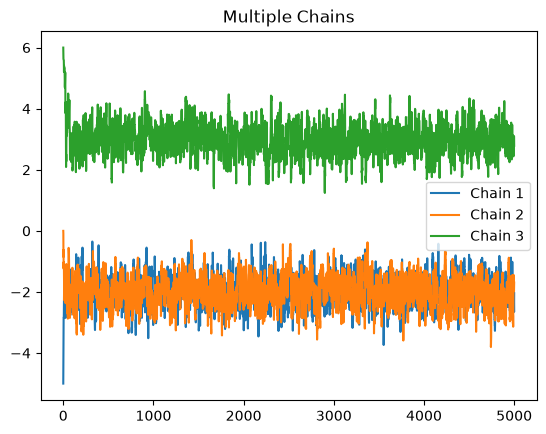

In [34]:
grid = np.linspace(0,5000,5000)
plt.plot(grid, c1, label='Chain 1')
plt.plot(grid, c2, label='Chain 2')
plt.plot(grid, c3, label='Chain 3')
plt.legend()
plt.title('Multiple Chains')

# Seems like chain 3 is converging to a different distribution than chains 1 and 2. 
# Or in other words, chain 3 got trapped at peak \theta = 3, and chains 1 and 2 got
# trapped at peak -2. This is classic MCMC failure happening before my very eyes!

**Burn in**

Given the plots, we will perform a burn-in of 1000. Which seems overkill but let us be safe about it.

Text(0.5, 1.0, 'Multiple Chains After Burn-In')

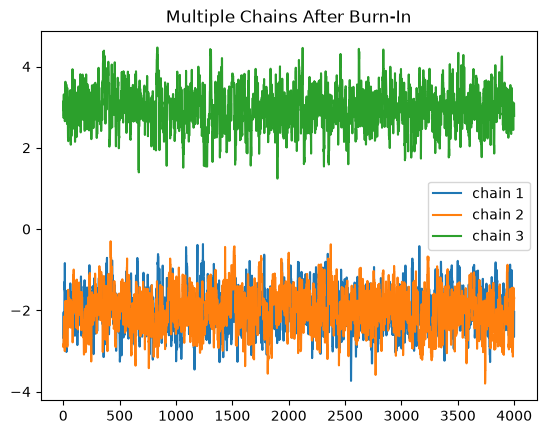

In [33]:
def burn_in(chain, burn):
    return chain[burn:]

c1_b = burn_in(c1, 1000)
c2_b = burn_in(c2, 1000)
c3_b = burn_in(c3, 1000)

grid_4000 = np.linspace(0,4000,4000)
plt.plot(grid_4000, c1_b, label='chain 1')
plt.plot(grid_4000, c2_b, label='chain 2')
plt.plot(grid_4000, c3_b, label='chain 3')
plt.legend()
plt.title('Multiple Chains After Burn-In')

### Diagnostics

#### ACF Plot

In [ ]:
# Lag 5 correlation
# CHAIN 1
c1_b_base = c1_b[:-5] # all elements except last 5  
c1_b_shift = c1_b[5:] # all elements except first 5

c_1_pearson_corr_lag5 = np.corrcoef(c1_b_base, c1_b_shift)[0, 1]
print(f"Chain 1 - Lag 5 :{c_1_pearson_corr_lag5}")

# CHAIN 2
c2_b_base = c2_b[:-5]  
c2_b_shift = c2_b[5:]

c_2_pearson_corr_lag5 = np.corrcoef(c2_b_base, c2_b_shift)[0, 1]
print(f"Chain 2 - Lag 5 :{c_2_pearson_corr_lag5}")

# CHAIN 3
c3_b_base = c3_b[:-5]  
c3_b_shift = c3_b[5:] 

c_3_pearson_corr_lag5 = np.corrcoef(c3_b_base, c3_b_shift)[0, 1]
print(f"Chain 3 - Lag 5 :{c_3_pearson_corr_lag5}")


Chain 1 - Lag 5 :0.24837009749751865
Chain 2 - Lag 5 :0.3478507127434401
Chain 3 - Lag 5 :0.3009611174795906


In [77]:
# Code to generate general ACF plot
def acf_plot(chain, num_lags):
    num_lags_range = np.array(range(1,num_lags+1))
    lag_vals = np.zeros((num_lags+1,))
    lag_vals[0] = 1.0 # Perfect correlation with itself

    # Computing autocorrelation
    for k in num_lags_range:
        chain_base = chain[:-k]
        chain_shift = chain[k:]
        chain_corr = np.corrcoef(chain_base, chain_shift)[0, 1]
        lag_vals[k] = chain_corr

    # Computing 95% CI on autocorrelation = 0.0 using Bartlett's formula
    N = len(chain)
    upper_bd = 1.96 / np.sqrt(N)
    lower_bd = -1.96 / np.sqrt(N)

    plt.stem(
        np.array(range(0, num_lags+1)),
        lag_vals,
        markerfmt='.',
        label='Chain 1',
    )
    # Add the confidence interval lines
    plt.axhline(y=upper_bd, color='red', linestyle='--', alpha=0.7, label='95% CI (Null = 0)')
    plt.axhline(y=lower_bd, color='red', linestyle='--', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3) # Zero baseline
    plt.xlabel('lag (k)')
    plt.ylabel('Autocorrelation')
    plt.legend()
    plt.title('Autocorrelation plot for Chain 1')
    plt.show()
    return lag_vals



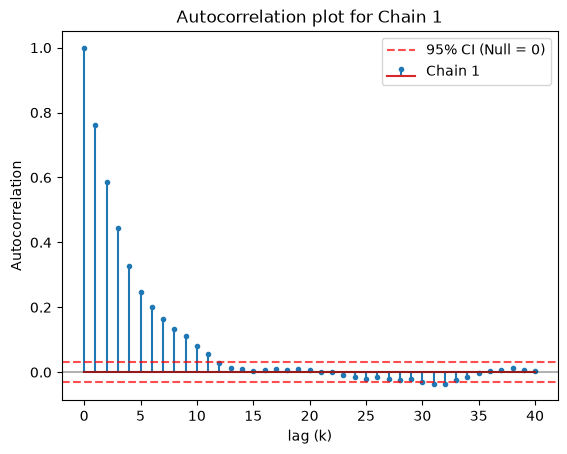

In [81]:
c1_acf_vals = acf_plot(c1_b, 40)

#### $\hat R$ - (Gelman-Rubin)

In [ ]:
all_chains = np.array([c1_b, c2_b, c3_b])
M, N = all_chains.shape
all_chains[[0,1,2], :10] # first ten states of each chain

array([[-2.67310197, -2.35337004, -2.0484639 , -2.0484639 , -2.0484639 ,
        -2.0484639 , -2.87301671, -2.45747319, -2.30167356, -2.19884661],
       [-2.84413489, -2.84413489, -2.90721198, -2.63472441, -2.63472441,
        -2.53324156, -2.21102527, -2.21102527, -2.15057259, -2.25179475],
       [ 2.75265866,  3.04633854,  3.1488951 ,  2.91706595,  3.0659178 ,
         3.31353027,  2.7879813 ,  2.7879813 ,  2.73785583,  3.00927101]])

In [112]:
chain_means = np.mean(all_chains, axis=1) # gives mean for each chain, stored in an array
grand_mean = np.mean(all_chains) # mean of states across all chains
# between-chain variance
B = (N / (M-1)) * np.sum((chain_means - grand_mean)**2)
# within-chain variance
chain_variances = np.var(all_chains, axis=1, ddof=1) # ddof=1 computes variance via N-1 degrees of freedom
W = (1/M) * np.sum(chain_variances)
# target variance estimate
target_var = ((N-1) / N)*W + (1/N)*B
# R hat calculation
r_hat = np.sqrt(target_var / W)
r_hat

np.float64(5.708515913534836)

In [113]:
# Code for general R hat computation
def gr_r_hat(all_chains):
    M, N = all_chains.shape
    chain_means = np.mean(all_chains, axis=1)
    grand_mean = np.mean(all_chains) # mean of states across all chains
    # between-chain variance
    B = (N / (M-1)) * np.sum((chain_means - grand_mean)**2)
    # within-chain variance
    chain_variances = np.var(all_chains, axis=1, ddof=1) # ddof=1 computes variance via N-1 degrees of freedom
    W = (1/M) * np.sum(chain_variances)
    # target variance estimate
    target_var = ((N-1) / N)*W + (1/N)*B
    # R hat calculation
    r_hat = np.sqrt(target_var / W)
    return r_hat

gr_r_hat(np.array([c1_b, c2_b, c3_b]))

np.float64(5.708515913534836)

#### ESS

Recall the ESS formula for a single chain of length N is
$$
    \operatorname{ESS} = \frac{N}{1 + 2 \sum_{k=1}^{\infty} \rho_k}
$$
where $\rho_k$ is the autocorrelation at lag $k$. 

In practice, since we cannot sum to infinity for the lags, we sum up the lags until the autocorrelation drops to near-zero. 

In [117]:
# general ESS computation
def calculate_ess(chain, max_lag=50):
    N = len(chain)
    rho_sum = 0
    for k in range(1, max_lag+1):
        chain_b = chain[:-k]
        chain_s = chain[k:]
        rho_k = np.corrcoef(chain_b, chain_s)[0, 1]
        rho_sum += rho_k

    return N / (1 + 2 * rho_sum)

ESS_c1 = calculate_ess(c1_b)
ESS_c2 = calculate_ess(c2_b)
ESS_c3 = calculate_ess(c3_b)
print(f"The effective sample size for chain 1 is: {ESS_c1:.0f}")
print(f"The effective sample size for chain 2 is: {ESS_c2:.0f}")
print(f"The effective sample size for chain 3 is: {ESS_c3:.0f}")

The effective sample size for chain 1 is: 555
The effective sample size for chain 2 is: 351
The effective sample size for chain 3 is: 625
